### Experiment_05

In [ ]:
from google.colab import userdata

In [ ]:
import os

os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_API_TOKEN')

In [ ]:
!pip install -q kaggle

In [ ]:
!kaggle datasets list

ref                                                                 title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
algozee/teenager-menthal-healy                                      Social Media Impact on Teen Mental Health                16190  2026-04-05 08:04:21.823000          19062        418                1  
sharmajicoder/gen-z-social-media-usage-dataset                      Gen-Z Social Media Usage Dataset                      44185801  2026-04-25 08:23:33.093000           1555         44                1  
maulikgajera/esports-world-cup-2025-dataset                         Esports World Cup 2025 Dataset                           20722  2026-05-02 17:17:36.950000            389         23

In [ ]:
!kaggle datasets download -d sauravagarwal/flower-classification

Dataset URL: https://www.kaggle.com/datasets/sauravagarwal/flower-classification
License(s): CC0-1.0
100% 219M/219M [00:01<00:00, 123MB/s]



In [ ]:
import zipfile

with zipfile.ZipFile("flower-classification.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/flowers_dataset")

print("Done!")

Done!


In [ ]:
BASE_PATH = "/content/flowers_dataset/flowers/flowers/flower_photos"

train_path = BASE_PATH + "/train"
val_path   = BASE_PATH + "/validation"
test_path  = BASE_PATH + "/test"

In [ ]:
import tensorflow as tf

IMG_SIZE = 128
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_path,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

Found 3540 files belonging to 5 classes.
Found 80 files belonging to 5 classes.
Found 50 files belonging to 5 classes.


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

def normalize(image, label):
    return tf.cast(image/255.0, tf.float32), label

train_ds = train_ds.map(normalize).cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.map(normalize).cache().prefetch(AUTOTUNE)
test_ds  = test_ds.map(normalize).cache().prefetch(AUTOTUNE)

In [ ]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [ ]:
from tensorflow import keras

base_model = keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model = keras.Sequential([
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(5, activation='softmax')
])

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_frozen = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.7082 - loss: 0.8676 - val_accuracy: 0.8625 - val_loss: 0.4522
Epoch 2/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.8167 - loss: 0.5156 - val_accuracy: 0.8375 - val_loss: 0.4340
Epoch 3/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.8517 - loss: 0.4124 - val_accuracy: 0.8375 - val_loss: 0.3894
Epoch 4/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.8743 - loss: 0.3535 - val_accuracy: 0.8500 - val_loss: 0.3684
Epoch 5/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.8833 - loss: 0.3132 - val_accuracy: 0.9000 - val_loss: 0.3382


In [ ]:
frozen_loss, frozen_acc = model.evaluate(test_ds)
print("Frozen Model Accuracy:", frozen_acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - accuracy: 0.8200 - loss: 0.6003
Frozen Model Accuracy: 0.8199999928474426


In [ ]:
base_model.trainable = True

# Freeze lower layers, unfreeze top layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),  # 🔥 VERY IMPORTANT
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 17s 51ms/step - accuracy: 0.7992 - loss: 0.5467 - val_accuracy: 0.8750 - val_loss: 0.3763
Epoch 2/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.8218 - loss: 0.4855 - val_accuracy: 0.8625 - val_loss: 0.4124
Epoch 3/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.8379 - loss: 0.4377 - val_accuracy: 0.8750 - val_loss: 0.4252
Epoch 4/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.8573 - loss: 0.4002 - val_accuracy: 0.8750 - val_loss: 0.4055
Epoch 5/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.8720 - loss: 0.3622 - val_accuracy: 0.9000 - val_loss: 0.3899


In [ ]:
finetune_loss, finetune_acc = model.evaluate(test_ds)

print("Frozen Accuracy :", frozen_acc)
print("Fine-tuned Accuracy :", finetune_acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8400 - loss: 0.6452
Frozen Accuracy : 0.8199999928474426
Fine-tuned Accuracy : 0.8399999737739563


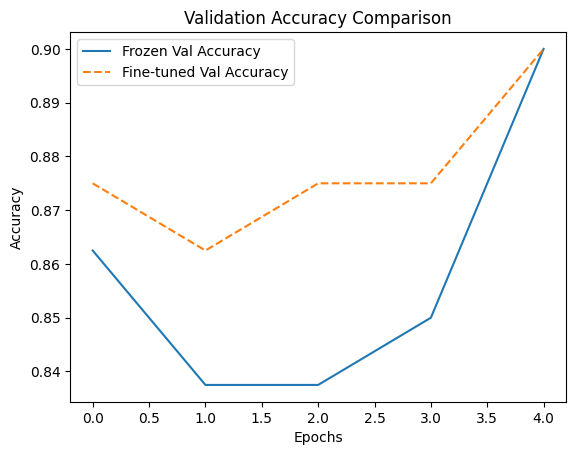

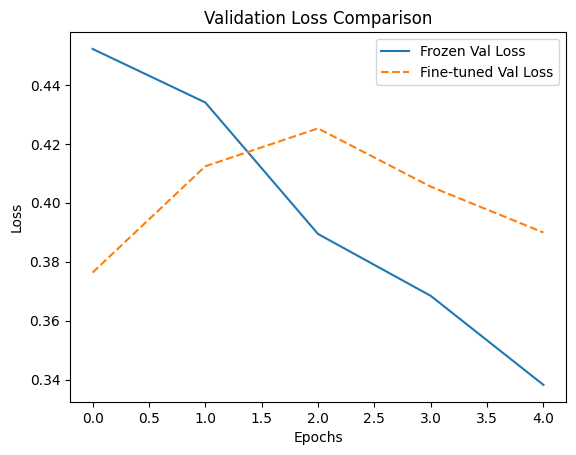

In [ ]:
import matplotlib.pyplot as plt

# Extract validation metrics
frozen_val_acc = history_frozen.history['val_accuracy']
frozen_val_loss = history_frozen.history['val_loss']

ft_val_acc = history_finetune.history['val_accuracy']
ft_val_loss = history_finetune.history['val_loss']

epochs_frozen = range(len(frozen_val_acc))
epochs_ft = range(len(ft_val_acc))

plt.figure()

plt.plot(epochs_frozen, frozen_val_acc, label='Frozen Val Accuracy')
plt.plot(epochs_ft, ft_val_acc, linestyle='--', label='Fine-tuned Val Accuracy')

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()


plt.figure()

plt.plot(epochs_frozen, frozen_val_loss, label='Frozen Val Loss')
plt.plot(epochs_ft, ft_val_loss, linestyle='--', label='Fine-tuned Val Loss')

plt.title("Validation Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

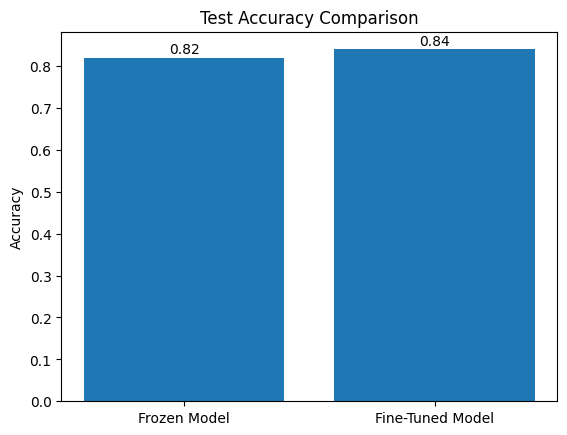

In [ ]:
models = ['Frozen Model', 'Fine-Tuned Model']
accuracies = [0.82, 0.84]

plt.figure()
plt.bar(models, accuracies)

plt.title("Test Accuracy Comparison")
plt.ylabel("Accuracy")

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()